# 7章　線形回帰

In [2]:
# 必要ライブラリの宣言
# 聲明所需的資料庫
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# waring抑止
import warnings
warnings.filterwarnings('ignore')

In [14]:
# 「ボストン・データセット」はscikit-learnのライブラリでも取得できるが、
# その場合、将来版で利用できなくなる予定のため、別Webサイトから取得する
# 「波士頓資料集」也可以從 scikit-learn 庫中獲取，
# 在這種情況下，它將在未來版本中不可用，因此請從其他網站取得它。
#data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv('BostonHousing.csv')
x_org = raw_df.values[:, :-1]
yt = raw_df.values[:, -1]
feature_names_x = raw_df.columns[:-1]

print('原始資料', x_org.shape, yt.shape)
print('特徵名稱：', feature_names_x)

# 資料過濾 (僅限 Item RM)
x_data = x_org[:,feature_names_x =='rm']
print('過濾後', x_data.shape)

# 新增虛擬變數
x = np.insert(x_data, 0, 1.0, axis=1)
print('加入虛擬變數後', x.shape)

原始資料 (506, 13) (506,)
特徵名稱： Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat'],
      dtype='object')
過濾後 (506, 1)
加入虛擬變數後 (506, 2)


In [15]:
# 入力データxの表示 (ダミー変数を含む)
# 顯示輸入資料x（包括虛擬變數）
print(x.shape)
print(x[:5,:])

(506, 2)
[[1.    6.575]
 [1.    6.421]
 [1.    7.185]
 [1.    6.998]
 [1.    7.147]]


In [16]:
# 正解データ yの表示
# 顯示正確資料 y
print(yt[:5])

[24.  21.6 34.7 33.4 36.2]


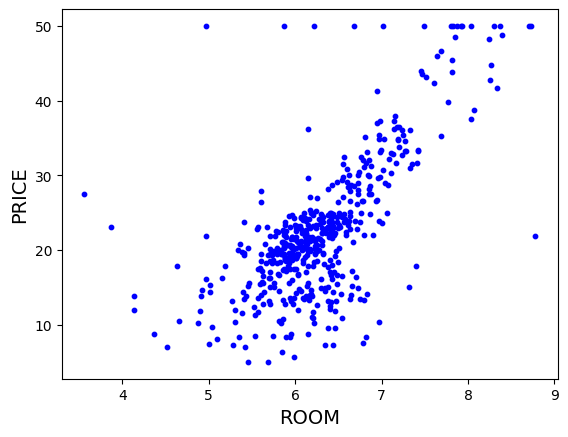

In [17]:
# 散布図の表示
# 散布圖的表示
plt.scatter(x[:,1], yt, s=10, c='b')
plt.xlabel('ROOM', fontsize=14)
plt.ylabel('PRICE', fontsize=14)
plt.show()

In [18]:
# 予測関数 (1, x)の値から予測値ypを計算する
# 根據預測函數（1，x）的值計算預測值yp

def pred(x, w):
    return(x @ w)

In [19]:
# 初期化処理
# 初始化過程

# データ系列総数
# 資料系列總數
M  = x.shape[0]

# 入力データ次元数(ダミー変数を含む)
# 輸入資料維數（包括虛擬變數）
D = x.shape[1]

# 繰り返し回数
# 重複次數
iters = 50000

# 学習率
# 學習率
alpha = 0.01

# 重みベクトルの初期値 (すべての値を1にする)
# 權重向量的初始值（所有值都設定為1）
w = np.ones(D)

# 評価結果記録用 (損失関数値のみ記録)
# 用於記錄評估結果（僅記錄損失函數值）
history = np.zeros((0,2))

In [20]:
# 繰り返しループ
# 重複循環
for k in range(iters):
    
    # 予測値の計算 (7.8.1)
    # 計算預測值（7.8.1）
    yp = pred(x, w)
    
    # 誤差の計算 (7.8.2)
    # 誤差計算（7.8.2）
    yd = yp - yt
    
    # 勾配降下法の実装 (7.8.4)
    # 實現梯度下降（7.8.4）
    w = w - alpha * (x.T @ yd) / M
    
    # 学習曲線描画用データの計算、保存
    # 計算並儲存資料以繪製學習曲線
    if ( k % 100 == 0):
        # 損失関数値の計算 (7.6.1)
        # 計算損失函數值（7.6.1）
        loss = np.mean(yd ** 2) / 2
        # 計算結果の記録
        # 記錄計算結果
        history = np.vstack((history, np.array([k, loss])))
        # 画面表示
        # 螢幕顯示
        print( "iter = %d  loss = %f" % (k, loss))    

iter = 0  loss = 154.224934
iter = 100  loss = 29.617518
iter = 200  loss = 29.431766
iter = 300  loss = 29.250428
iter = 400  loss = 29.073399
iter = 500  loss = 28.900577
iter = 600  loss = 28.731861
iter = 700  loss = 28.567154
iter = 800  loss = 28.406360
iter = 900  loss = 28.249388
iter = 1000  loss = 28.096145
iter = 1100  loss = 27.946544
iter = 1200  loss = 27.800498
iter = 1300  loss = 27.657922
iter = 1400  loss = 27.518733
iter = 1500  loss = 27.382852
iter = 1600  loss = 27.250200
iter = 1700  loss = 27.120700
iter = 1800  loss = 26.994277
iter = 1900  loss = 26.870858
iter = 2000  loss = 26.750372
iter = 2100  loss = 26.632749
iter = 2200  loss = 26.517921
iter = 2300  loss = 26.405821
iter = 2400  loss = 26.296385
iter = 2500  loss = 26.189549
iter = 2600  loss = 26.085252
iter = 2700  loss = 25.983433
iter = 2800  loss = 25.884034
iter = 2900  loss = 25.786997
iter = 3000  loss = 25.692265
iter = 3100  loss = 25.599784
iter = 3200  loss = 25.509501
iter = 3300  loss = 2

In [ ]:
# 最終的な損失関数初期値、最終値
# 最終損失函數初值，最終值
print('損失関数初期値: %f' % history[0,1])
print('損失関数最終値: %f' % history[-1,1])

損失関数初期値: 154.224934
損失関数最終値: 21.800325


In [ ]:
# 下記直線描画用の座標値計算
# 計算繪製以下線條的座標
xall = x[:,1].ravel()
xl = np.array([[1, xall.min()],[1, xall.max()]])
yl = pred(xl, w)

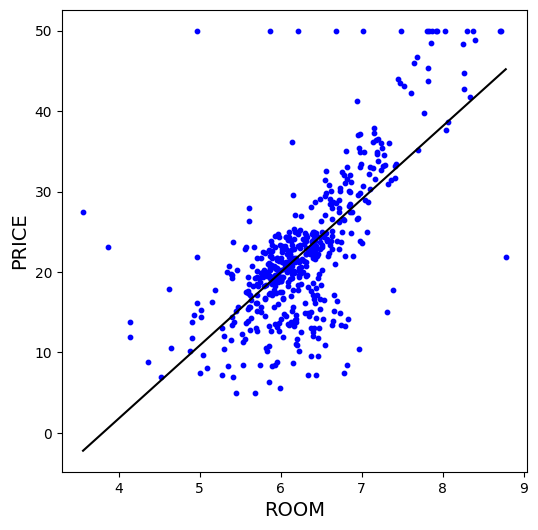

In [ ]:
# 散布図と回帰直線の描画
# 繪製散佈圖和迴歸線
plt.figure(figsize=(6,6))
plt.scatter(x[:,1], yt, s=10, c='b')
plt.xlabel('ROOM', fontsize=14)
plt.ylabel('PRICE', fontsize=14)
plt.plot(xl[:,1], yl, c='k')
plt.show()

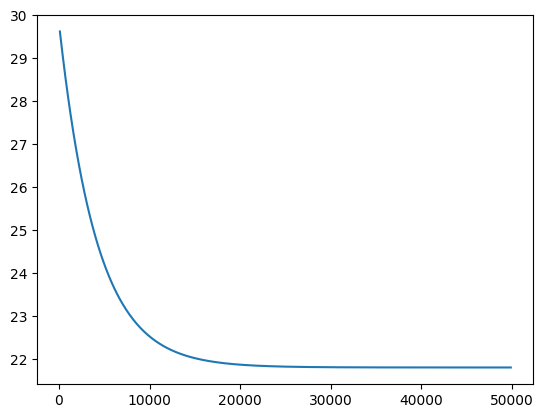

In [ ]:
# 学習曲線の表示 (最初の1個分を除く)
# 顯示學習曲線（第一個除外）
plt.plot(history[1:,0], history[1:,1])
plt.show()

## 7.10  重回帰モデルへの拡張

In [ ]:
# 列(LSTAT: 低所得者率)の追加
# 新增列（LSTAT：低收入率）
x_add = x_org[:,feature_names == 'LSTAT']
x2 = np.hstack((x, x_add))
print(x2.shape)

(506, 2)


In [ ]:
# 入力データxの表示 (ダミーデータを含む)
# 顯示輸入資料x（包含虛擬資料）
print(x2[:5,:])

[[1.    6.575]
 [1.    6.421]
 [1.    7.185]
 [1.    6.998]
 [1.    7.147]]


In [ ]:
# 初期化処理
# 初始化過程

# データ系列総数
# 資料系列總數
M  = x2.shape[0]

# 入力データ次元数(ダミー変数を含む)
# 輸入資料維數（包括虛擬變數）
D = x2.shape[1]

# 繰り返し回数
# 重複次數
iters = 50000

# 学習率
# 學習率
alpha = 0.01

# 重みベクトルの初期値 (すべての値を1にする)
# 權重向量的初始值（將所有值設為1）
w = np.ones(D)

# 評価結果記録用 (損失関数値のみ記録)
# 用於記錄評估結果（僅記錄損失函數值）
history = np.zeros((0,2))

In [ ]:
# 繰り返しループ
# 重複循環
for k in range(iters):
    
    # 予測値の計算 (7.8.1)
    # 計算預測值（7.8.1）
    yp = pred(x2, w)
    
    # 誤差の計算 (7.8.2)
    # 誤差計算（7.8.2）
    yd = yp - yt
    
    # 勾配降下法の実装 (7.8.4)
    # 實現梯度下降（7.8.4）
    w = w - alpha * (x2.T @ yd) / M
    
    # 学習曲線描画用データの計算、保存
    # 計算並儲存資料以繪製學習曲線
    if ( k % 100 == 0):
        # 損失関数値の計算 (7.6.1)
        # 計算損失函數值（7.6.1）
        loss = np.mean(yd ** 2) / 2
        # 計算結果の記録
        # 記錄計算結果
        history = np.vstack((history, np.array([k, loss])))
        # 画面表示
        # 螢幕顯示
        print( "iter = %d  loss = %f" % (k, loss))    

iter = 0  loss = 154.224934
iter = 100  loss = 29.617518
iter = 200  loss = 29.431766
iter = 300  loss = 29.250428
iter = 400  loss = 29.073399
iter = 500  loss = 28.900577
iter = 600  loss = 28.731861
iter = 700  loss = 28.567154
iter = 800  loss = 28.406360
iter = 900  loss = 28.249388
iter = 1000  loss = 28.096145
iter = 1100  loss = 27.946544
iter = 1200  loss = 27.800498
iter = 1300  loss = 27.657922
iter = 1400  loss = 27.518733
iter = 1500  loss = 27.382852
iter = 1600  loss = 27.250200
iter = 1700  loss = 27.120700
iter = 1800  loss = 26.994277
iter = 1900  loss = 26.870858
iter = 2000  loss = 26.750372
iter = 2100  loss = 26.632749
iter = 2200  loss = 26.517921
iter = 2300  loss = 26.405821
iter = 2400  loss = 26.296385
iter = 2500  loss = 26.189549
iter = 2600  loss = 26.085252
iter = 2700  loss = 25.983433
iter = 2800  loss = 25.884034
iter = 2900  loss = 25.786997
iter = 3000  loss = 25.692265
iter = 3100  loss = 25.599784
iter = 3200  loss = 25.509501
iter = 3300  loss = 2

In [ ]:
# 初期化処理 (パラメータを適切な値に変更)
# 初始化過程（將參數改為適當的值）

# データ系列総数
# 資料系列總數
M  = x2.shape[0]

# 入力データ次元数(ダミー変数を含む)
# 輸入資料維數（包括虛擬變數）
D = x2.shape[1]

# 繰り返し回数
# 重複次數
#iters = 50000
iters = 2000

# 学習率
# 學習率
#alpha = 0.01
alpha = 0.001

# 重みベクトルの初期値 (すべての値を1にする)
# 權重向量的初始值（將所有值設為1）
w = np.ones(D)

# 評価結果記録用 (損失関数値のみ記録)
# 用於記錄評估結果（僅記錄損失函數值）
history = np.zeros((0,2))

In [ ]:
# 繰り返しループ
# 重複循環
for k in range(iters):
    
    # 予測値の計算 (7.8.1)
    # 計算預測值（7.8.1）
    yp = pred(x2, w)
    
    # 誤差の計算 (7.8.2)
    # 誤差計算（7.8.2）
    yd = yp - yt
    
    # 勾配降下法の実装 (7.8.4)
    # 實現梯度下降（7.8.4）
    w = w - alpha * (x2.T @ yd) / M
    
    # 学習曲線描画用データの計算、保存
    # 計算並儲存資料以繪製學習曲線
    if ( k % 100 == 0):
        # 損失関数値の計算 (7.6.1)
        # 計算損失函數值（7.6.1）
        loss = np.mean(yd ** 2) / 2
        # 計算結果の記録
        # 記錄計算結果
        history = np.vstack((history, np.array([k, loss])))
        # 画面表示
        # 螢幕顯示
        print( "iter = %d  loss = %f" % (k, loss))    

iter = 0  loss = 154.224934
iter = 100  loss = 29.817442
iter = 200  loss = 29.769378
iter = 300  loss = 29.750231
iter = 400  loss = 29.731136
iter = 500  loss = 29.712088
iter = 600  loss = 29.693085
iter = 700  loss = 29.674127
iter = 800  loss = 29.655216
iter = 900  loss = 29.636349
iter = 1000  loss = 29.617528
iter = 1100  loss = 29.598752
iter = 1200  loss = 29.580022
iter = 1300  loss = 29.561336
iter = 1400  loss = 29.542695
iter = 1500  loss = 29.524099
iter = 1600  loss = 29.505547
iter = 1700  loss = 29.487040
iter = 1800  loss = 29.468578
iter = 1900  loss = 29.450160


In [ ]:
# 最終的な損失関数初期値、最終値
# 最終損失函數初值，最終值
print('損失関数初期値: %f' % history[0,1])
print('損失関数最終値: %f' % history[-1,1])

損失関数初期値: 154.224934
損失関数最終値: 29.450160


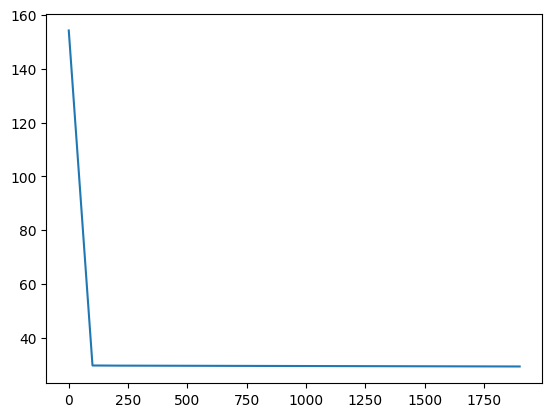

In [ ]:
# 学習曲線の表示 (最初の10個分を除く)
# 顯示學習曲線（不含前10條）
plt.plot(history[:,0], history[:,1])
plt.show()